# Classical Classification and Matching (No ML)

Recognition **without training**: compare templates, histograms, or local features.

**Image sources:** `skimage.data.chelsea`, ECE533 `peppers`.

**Not covered:** SVM, k-NN training, neural networks.

---

## 1. Template matching

Slide a template over the image; compute similarity at each position.

`cv2.matchTemplate(image, template, method)`

| Method | Idea |
|--------|------|
| `TM_CCOEFF_NORMED` | normalized correlation (−1 to 1, peak = match) |
| `TM_SQDIFF_NORMED` | normalized squared difference (minimum = match) |

**Algorithms in this notebook:** template matching (all methods), histogram compare & backprojection, ORB/AKAZE feature matching, Hu moments, Hough circles, rule-based labeling.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from urllib.request import urlretrieve
import skimage.data as skid

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NOTEBOOK_DIR = Path.cwd()
IMAGES_CACHE = NOTEBOOK_DIR.parent / "Images"
IMAGES_CACHE.mkdir(exist_ok=True)

ECE533_URLS = {
    "peppers": "https://homepages.cae.wisc.edu/~ece533/images/peppers.png",
    "boat": "https://homepages.cae.wisc.edu/~ece533/images/boat.png",
    "baboon": "https://homepages.cae.wisc.edu/~ece533/images/baboon.png",
}

SKIMAGE_FALLBACK = {
    "peppers": skid.astronaut,
    "boat": skid.camera,
    "baboon": skid.chelsea,
}


def load_sample_image(name):
    """Load from skimage.data or download Wisconsin ECE533 image (cached locally)."""
    skimg_map = {
        "camera": skid.camera,
        "coins": skid.coins,
        "astronaut": skid.astronaut,
        "coffee": skid.coffee,
        "chelsea": skid.chelsea,
        "page": skid.page,
    }
    if name in skimg_map:
        img = skimg_map[name]()
        if img.ndim == 2:
            return img.astype(np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cache_path = IMAGES_CACHE / f"{name}.png"
    if cache_path.exists():
        img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
        if img is not None:
            return img

    url = ECE533_URLS.get(name)
    if url:
        try:
            print(f"Downloading {name} from ECE533 ...")
            urlretrieve(url, cache_path)
            img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
            if img is not None:
                return img
        except Exception as exc:
            print(f"Download failed ({exc}); using skimage fallback.")

    fallback = SKIMAGE_FALLBACK.get(name, skid.camera)
    img = fallback()
    if img.ndim == 2:
        return img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)


def to_rgb(bgr):
    if bgr.ndim == 2:
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def show_gray(ax, img, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


def show_rgb(ax, img_bgr, title=""):
    ax.imshow(to_rgb(img_bgr))
    ax.set_title(title)
    ax.axis("off")


def side_by_side(images, titles, rgb_flags=None, cols=4):
    """Plot a row/grid of images. images: list of arrays; rgb_flags: True for BGR color."""
    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, (img, title) in enumerate(zip(images, titles)):
        is_rgb = rgb_flags[i] if rgb_flags else (img.ndim == 3)
        if is_rgb:
            show_rgb(axes[i], img, title)
        else:
            show_gray(axes[i], img, title)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


def add_salt_pepper(gray, amount=0.05):
    """Inject salt-and-pepper noise into a uint8 grayscale image."""
    out = gray.copy()
    n = int(amount * gray.size)
    rng = np.random.default_rng(42)
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 255
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 0
    return out


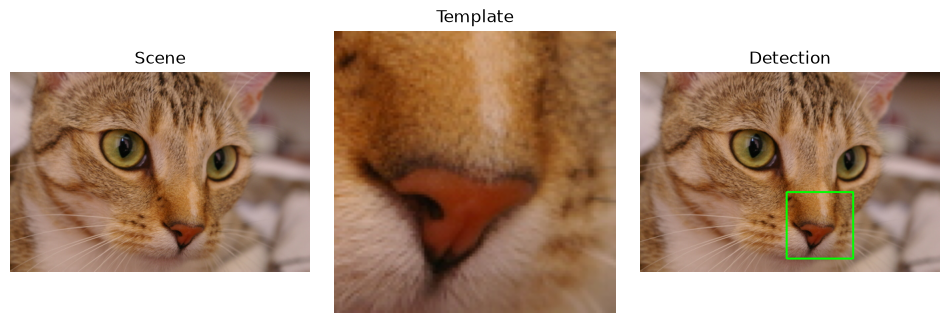

Peaks in heatmaps = likely template location. Prefer *_NORMED methods (lighting robust).


In [10]:
chelsea = load_sample_image("chelsea")
tpl = chelsea[180:280, 220:320].copy()
th, tw = tpl.shape[:2]

methods = [
    (cv2.TM_CCOEFF_NORMED, "CCOEFF_NORMED", True),
    (cv2.TM_CCORR_NORMED, "CCORR_NORMED", True),
    (cv2.TM_SQDIFF_NORMED, "SQDIFF_NORMED", False),
    (cv2.TM_CCOEFF, "CCOEFF", True),
    (cv2.TM_SQDIFF, "SQDIFF", False),
]

heatmaps, titles = [], []
best_marked = chelsea.copy()
for method, name, max_is_best in methods:
    res = cv2.matchTemplate(chelsea, tpl, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    score, loc = (max_val, max_loc) if max_is_best else (min_val, min_loc)
    heatmaps.append(res)
    titles.append(f"{name}\nscore={score:.3f}")
    cv2.rectangle(best_marked, loc, (loc[0] + tw, loc[1] + th), (0, 255, 0), 2)

side_by_side([chelsea, tpl, best_marked], ["Scene", "Template", "Detection"], rgb_flags=[True, True, True])

print("Peaks in heatmaps = likely template location. Prefer *_NORMED methods (lighting robust).")


## 2. Histogram comparison — “do two patches look similar in color?”

**Goal:** compare two image **patches** without ML — only by their **color statistics**.

### Step 1 — What is a color histogram?

Throw away *where* each pixel is; keep only **how often** each color appears.

For each patch we count pixels in B, G, R bins (here 32 bins per channel). Two patches with similar color mixes → similar histograms.

### Step 2 — Three patches from the same image

| Patch | What it is | Expectation |
|-------|------------|-------------|
| **crop_a** | 100×100 square at `(50,50)` | reference |
| **crop_b** | same size, shifted to `(80,80)` | **overlaps** crop_a → mostly same colors → histograms should match |
| **crop_diff** | same place as crop_a, but image was **blurred** first | same rough colors, **different** fine detail → histograms may differ less than you expect |

Histograms capture **color distribution**, not **texture/shape**. That is their strength and their limit.

### Step 3 — `cv2.compareHist`

Build a 3D BGR histogram (`calcHist`, 8×8×8 bins), then score similarity:

| Method | Similar when… | Typical range |
|--------|---------------|---------------|
| `HISTCMP_CORREL` | value **→ 1** | −1 … 1 |
| `HISTCMP_CHISQR` | value **→ 0** | 0 … ∞ |
| `HISTCMP_INTERSECT` | value **→ higher** | 0 … 1 |
| `HISTCMP_BHATTACHARYYA` | value **→ 0** | 0 … 1 |

**Read the printed table:** crop_a vs crop_b should score “more similar” than crop_a vs crop_diff (especially on CORREL / BHATTACHARYYA).


Download failed (HTTP Error 403: Forbidden); using skimage fallback.
Three 100×100 patches:
  crop_a      — top-left region (green box)
  crop_b      — shifted 30 px → overlaps crop_a (red box)
  crop_diff   — same region as crop_a, but taken from a blurred image


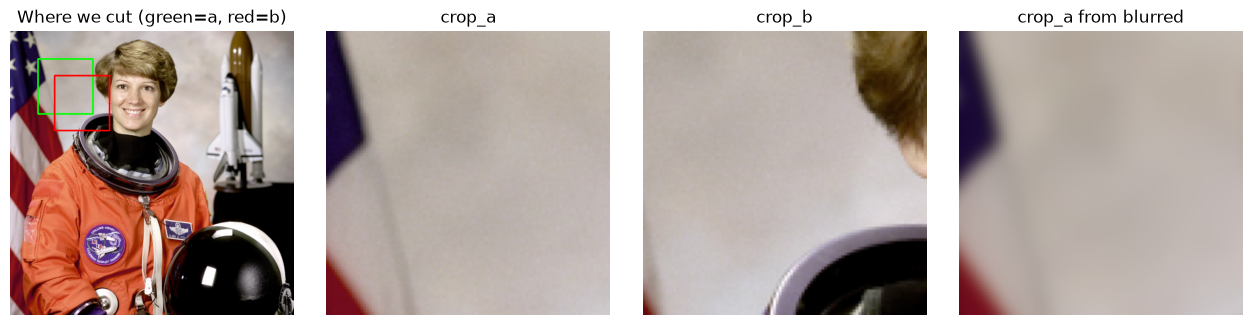

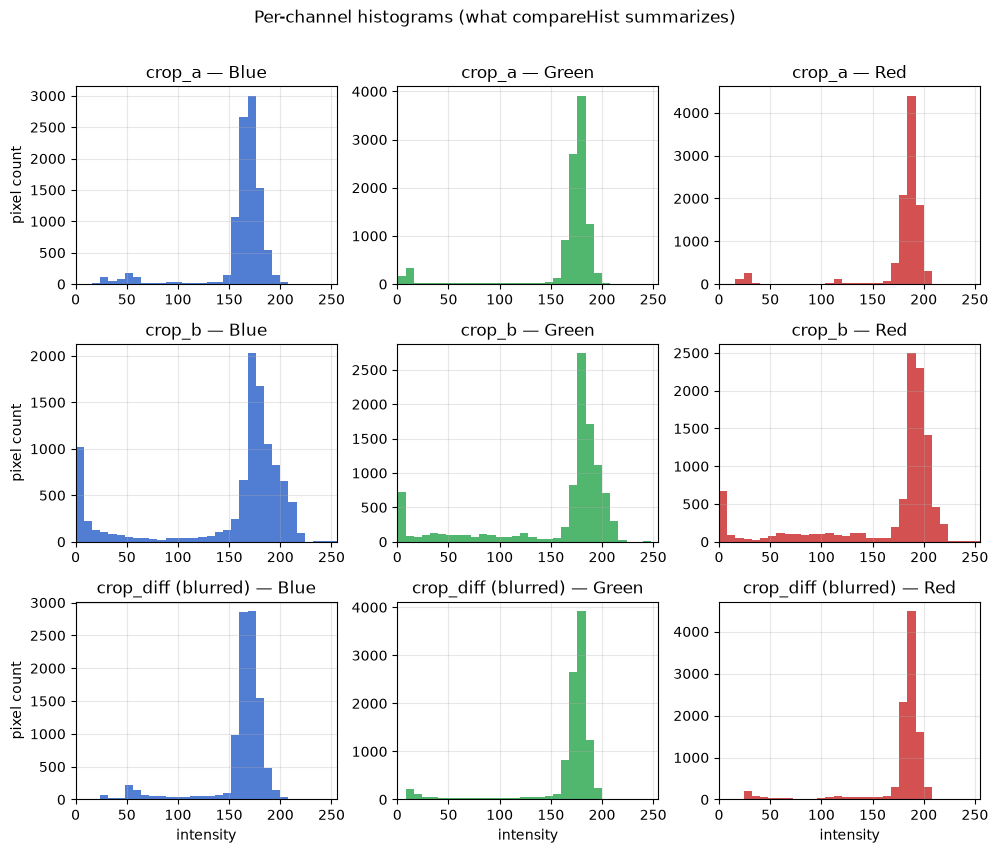


A) crop_a vs crop_b  — overlapping regions (expect SIMILAR)
Method            Score  How to read
------------------------------------------
CORREL           0.8218  (higher → more similar)
CHISQR         274107.1704  (lower → more similar)
INTERSECT      5629.0000  (higher → more similar)
BHATTACHARYYA    0.4573  (lower → more similar)

B) crop_a vs crop_diff — blur changed texture (expect LESS similar)
Method            Score  How to read
------------------------------------------
CORREL           0.9978  (higher → more similar)
CHISQR         1800.4041  (lower → more similar)
INTERSECT      9318.0000  (higher → more similar)
BHATTACHARYYA    0.1088  (lower → more similar)

Takeaway (CORREL): overlap=0.822, blurred=0.998 → unexpected — check image download/fallback


In [11]:
# --- Load image and cut 3 patches ---
peppers = load_sample_image("peppers")
if peppers.ndim == 2:
    peppers = cv2.cvtColor(peppers, cv2.COLOR_GRAY2BGR)

crop_a = peppers[50:150, 50:150]                          # reference square
crop_b = peppers[80:180, 80:180]                          # shifted → overlaps crop_a
crop_diff = cv2.GaussianBlur(peppers, (15, 15), 0)[50:150, 50:150]  # same box, blurred source

peppers_marked = peppers.copy()
cv2.rectangle(peppers_marked, (50, 50), (149, 149), (0, 255, 0), 2)
cv2.rectangle(peppers_marked, (80, 80), (179, 179), (0, 0, 255), 2)

print("Three 100×100 patches:")
print("  crop_a      — top-left region (green box)")
print("  crop_b      — shifted 30 px → overlaps crop_a (red box)")
print("  crop_diff   — same region as crop_a, but taken from a blurred image")

side_by_side(
    [peppers_marked, crop_a, crop_b, crop_diff],
    ["Where we cut (green=a, red=b)", "crop_a", "crop_b", "crop_a from blurred"],
    rgb_flags=[True, True, True, True],
    cols=4,
)

# --- Visualize what the histogram actually is: B/G/R bar charts per patch ---
def plot_channel_histograms(images, row_titles):
    fig, axes = plt.subplots(len(images), 3, figsize=(10, 2.8 * len(images)))
    if len(images) == 1:
        axes = axes.reshape(1, -1)
    ch_names = ["Blue", "Green", "Red"]
    ch_colors = ["#3366cc", "#33aa55", "#cc3333"]
    for row, (img, title) in enumerate(zip(images, row_titles)):
        for col, (name, color) in enumerate(zip(ch_names, ch_colors)):
            axes[row, col].hist(img[:, :, col].ravel(), bins=32, range=(0, 256),
                                color=color, alpha=0.85)
            axes[row, col].set_xlim(0, 255)
            axes[row, col].set_title(f"{title} — {name}")
            if col == 0:
                axes[row, col].set_ylabel("pixel count")
            if row == len(images) - 1:
                axes[row, col].set_xlabel("intensity")
    plt.suptitle("Per-channel histograms (what compareHist summarizes)", y=1.01)
    plt.tight_layout()
    plt.show()

plot_channel_histograms(
    [crop_a, crop_b, crop_diff],
    ["crop_a", "crop_b", "crop_diff (blurred)"],
)

# --- OpenCV: 3D BGR histogram (8×8×8 = 512 bins) + compareHist ---
def hist_bgr(img):
    return cv2.calcHist([img], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])

h_a, h_b, h_d = hist_bgr(crop_a), hist_bgr(crop_b), hist_bgr(crop_diff)

METHODS = [
    (cv2.HISTCMP_CORREL, "CORREL", "higher → more similar", lambda v: v),
    (cv2.HISTCMP_CHISQR, "CHISQR", "lower → more similar", lambda v: -v),
    (cv2.HISTCMP_INTERSECT, "INTERSECT", "higher → more similar", lambda v: v),
    (cv2.HISTCMP_BHATTACHARYYA, "BHATTACHARYYA", "lower → more similar", lambda v: -v),
]

def print_comparison(h1, h2, title):
    print(f"\n{title}")
    print(f"{'Method':<14} {'Score':>8}  How to read")
    print("-" * 42)
    for code, name, hint, _ in METHODS:
        print(f"{name:<14} {cv2.compareHist(h1, h2, code):8.4f}  ({hint})")

print_comparison(h_a, h_b, "A) crop_a vs crop_b  — overlapping regions (expect SIMILAR)")
print_comparison(h_a, h_d, "B) crop_a vs crop_diff — blur changed texture (expect LESS similar)")

# One-line takeaway using CORREL (most intuitive: 1 = identical histogram)
corr_ab = cv2.compareHist(h_a, h_b, cv2.HISTCMP_CORREL)
corr_ad = cv2.compareHist(h_a, h_d, cv2.HISTCMP_CORREL)
print(f"\nTakeaway (CORREL): overlap={corr_ab:.3f}, blurred={corr_ad:.3f}"
      f" → {'overlap wins' if corr_ab > corr_ad else 'unexpected — check image download/fallback'}")


## 3. ORB feature matching

**ORB** detects keypoints and binary descriptors. Match with brute force + **ratio test** (Lowe) to reject ambiguous matches.


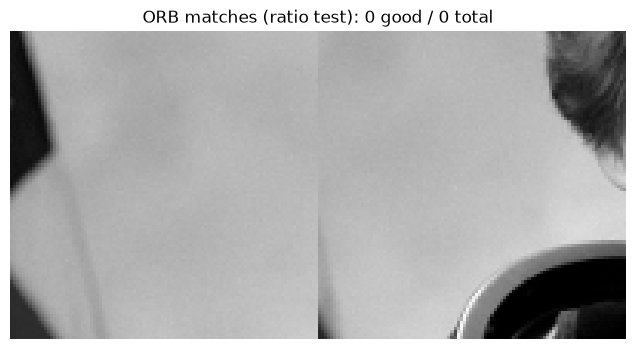

In [16]:
orb = cv2.ORB_create(nfeatures=500)
img1 = cv2.cvtColor(crop_a, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(crop_b, cv2.COLOR_BGR2GRAY)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2)
good = [m for m, n in matches if m.distance < 0.75 * n.distance]
matched = cv2.drawMatches(img1, kp1, img2, kp2, good, None,
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(10, 4))
plt.imshow(matched, cmap="gray")
plt.title(f"ORB matches (ratio test): {len(good)} good / {len(matches)} total")
plt.axis("off")
plt.show()


## 4. Histogram backprojection

**Goal:** find all pixels whose color **matches a reference patch** (e.g. crop_a from §2).

1. Build 2D Hue-Saturation histogram of the reference patch
2. `cv2.calcBackProject` — each pixel gets a score = how well it matches
3. Threshold → binary mask

Used in camshift tracking and color-based object search.

Download failed (HTTP Error 403: Forbidden); using skimage fallback.


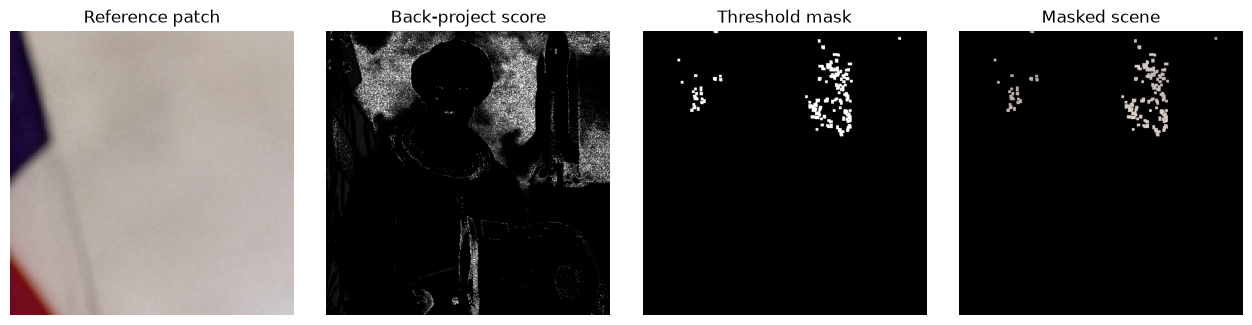

In [20]:
# Reference patch from peppers (run §2 first, or recreate here)
peppers_bp = load_sample_image("peppers")
if peppers_bp.ndim == 2:
    peppers_bp = cv2.cvtColor(peppers_bp, cv2.COLOR_GRAY2BGR)
ref = peppers_bp[50:150, 50:150]

hsv_scene = cv2.cvtColor(peppers_bp, cv2.COLOR_BGR2HSV)
hsv_ref = cv2.cvtColor(ref, cv2.COLOR_BGR2HSV)
hist_ref = cv2.calcHist([hsv_ref], [0, 1], None, [50, 60], [0, 180, 0, 256])
cv2.normalize(hist_ref, hist_ref, 0, 255, cv2.NORM_MINMAX)

backproj = cv2.calcBackProject([hsv_scene], [0, 1], hist_ref, [0, 180, 0, 256], 1.0)
_, bp_mask = cv2.threshold(backproj, 60, 255, cv2.THRESH_BINARY)
bp_mask = cv2.morphologyEx(bp_mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
highlight = cv2.bitwise_and(peppers_bp, peppers_bp, mask=bp_mask)

side_by_side(
    [ref, backproj, bp_mask, highlight],
    ["Reference patch", "Back-project score", "Threshold mask", "Masked scene"],
    rgb_flags=[True, False, False, True],
    cols=4,
)

## 5. AKAZE feature matching

**AKAZE** (like ORB) detects keypoints + binary descriptors; often more repeatable on blurry/noisy images.

Compare with **§3 ORB** on the same pepper crops — same ratio test (Lowe).

Download failed (HTTP Error 403: Forbidden); using skimage fallback.


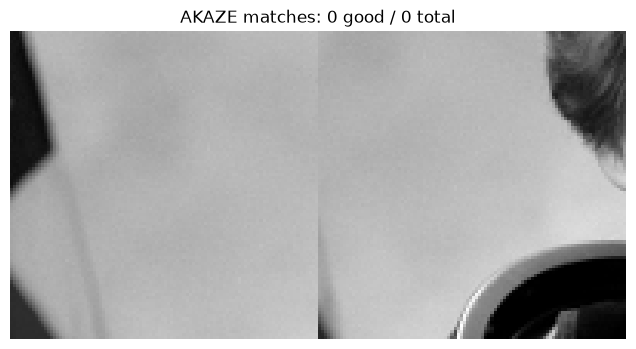

In [21]:
# Same crops as ORB section
peppers_ak = load_sample_image("peppers")
if peppers_ak.ndim == 2:
    peppers_ak = cv2.cvtColor(peppers_ak, cv2.COLOR_GRAY2BGR)
img1g = cv2.cvtColor(peppers_ak[50:150, 50:150], cv2.COLOR_BGR2GRAY)
img2g = cv2.cvtColor(peppers_ak[80:180, 80:180], cv2.COLOR_BGR2GRAY)

akaze = cv2.AKAZE_create()
kp1, des1 = akaze.detectAndCompute(img1g, None)
kp2, des2 = akaze.detectAndCompute(img2g, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2) if des1 is not None and des2 is not None else []
good_ak = [m for m, n in matches if m.distance < 0.75 * n.distance]

matched_ak = cv2.drawMatches(
    img1g, kp1, img2g, kp2, good_ak[:40], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
plt.figure(figsize=(10, 4))
plt.imshow(matched_ak, cmap="gray")
plt.title(f"AKAZE matches: {len(good_ak)} good / {len(matches)} total")
plt.axis("off")
plt.show()

## 6. Hu moments — shape matching

**Hu moments** are 7 numbers invariant to scale, rotation, and reflection — they describe **shape** not color.

`cv2.matchShapes(contour_a, contour_b, method, 0)` → distance (lower = more similar shape).

Shape distance to template coin (lower = more similar):
  #1 contour 3: distance=0.0261, area=2
  #2 contour 2: distance=0.0261, area=2
  #3 contour 5: distance=0.5275, area=0
  #4 contour 4: distance=0.5275, area=0
  #5 contour 1: distance=1.9178, area=4


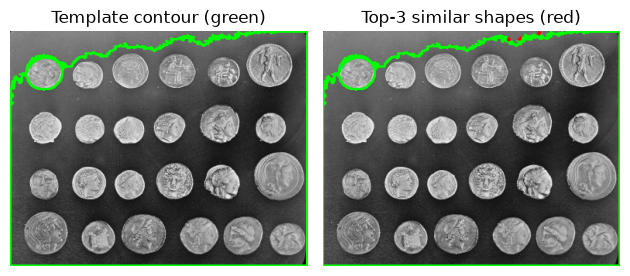

In [22]:
coins_hu = load_sample_image("coins")
_, bin_coins = cv2.threshold(coins_hu, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(bin_coins, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Template: first large coin contour
template_cnt = contours[0]
vis = cv2.cvtColor(coins_hu, cv2.COLOR_GRAY2BGR)
cv2.drawContours(vis, [template_cnt], -1, (0, 255, 0), 2)

scores = []
for i, cnt in enumerate(contours[1:8]):
    d = cv2.matchShapes(template_cnt, cnt, cv2.CONTOURS_MATCH_I1, 0)
    scores.append((i + 1, d, cv2.contourArea(cnt)))

scores.sort(key=lambda x: x[1])
print("Shape distance to template coin (lower = more similar):")
for rank, (idx, dist, area) in enumerate(scores[:5], 1):
    print(f"  #{rank} contour {idx}: distance={dist:.4f}, area={area:.0f}")

marked_hu = vis.copy()
for idx, dist, _ in scores[:3]:
    cv2.drawContours(marked_hu, [contours[idx]], -1, (0, 0, 255), 2)
side_by_side([vis, marked_hu], ["Template contour (green)", "Top-3 similar shapes (red)"], rgb_flags=[True, True])

## 7. Hough transform — parametric detection

Detect **analytic shapes** by voting in parameter space.

| Transform | Finds | OpenCV |
|-----------|-------|--------|
| Hough circles | Coins, balls | `cv2.HoughCircles` |
| Hough lines | Edges, lanes | `cv2.HoughLinesP` |

Here: circle Hough on `coins` — each detected circle is a segmented disk.

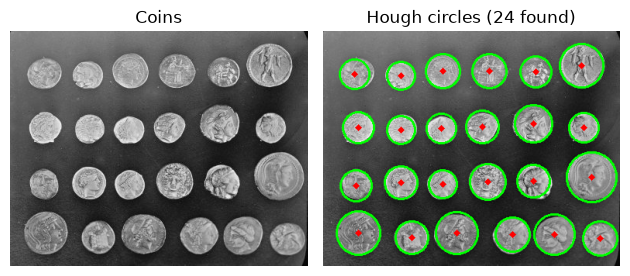

Tune param2 (accumulator threshold) if you get too many / too few circles.


In [23]:
coins_h = load_sample_image("coins")
blur_h = cv2.medianBlur(coins_h, 5)
circles = cv2.HoughCircles(
    blur_h, cv2.HOUGH_GRADIENT, dp=1.2, minDist=20,
    param1=100, param2=30, minRadius=10, maxRadius=45,
)
hough_vis = cv2.cvtColor(coins_h, cv2.COLOR_GRAY2BGR)
n_circles = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    n_circles = circles.shape[1]
    for x, y, r in circles[0]:
        cv2.circle(hough_vis, (x, y), r, (0, 255, 0), 2)
        cv2.circle(hough_vis, (x, y), 2, (0, 0, 255), 3)

side_by_side([coins_h, hough_vis], ["Coins", f"Hough circles ({n_circles} found)"], rgb_flags=[False, True])
print("Tune param2 (accumulator threshold) if you get too many / too few circles.")

## 8. Rule-based labeling

Combine simple rules (color + size) to assign labels — no learning.


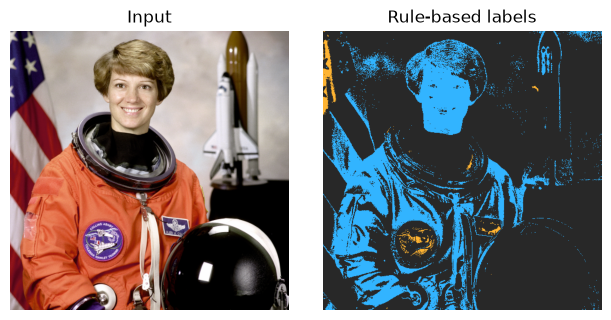

  other: 205889 px
  sky (blue): 2341 px
  skin tone: 53914 px


In [24]:
scene = load_sample_image("astronaut")
hsv = cv2.cvtColor(scene, cv2.COLOR_BGR2HSV)
# Rule 1: blue sky — high H in blue range, low saturation ok
sky_mask = cv2.inRange(hsv, (90, 30, 80), (130, 255, 255))
# Rule 2: skin-ish — orange hue
skin_mask = cv2.inRange(hsv, (0, 30, 60), (20, 180, 255))
labels_img = np.zeros(scene.shape[:2], dtype=np.int32)
labels_img[sky_mask > 0] = 1
labels_img[skin_mask > 0] = 2
label_names = {0: "other", 1: "sky (blue)", 2: "skin tone"}
color_map = np.array([[40, 40, 40], [255, 180, 50], [50, 180, 255]], dtype=np.uint8)
vis = color_map[labels_img]
vis_bgr = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
side_by_side([scene, vis_bgr], ["Input", "Rule-based labels"], rgb_flags=[True, True])
for lid, name in label_names.items():
    print(f"  {name}: {(labels_img == lid).sum()} px")


## 9. Summary

| Approach | Needs template? | Handles scale/rotation | Speed |
|----------|-----------------|------------------------|-------|
| Template matching | Yes (image patch) | Poor (same scale/orientation) | Fast |
| Histogram compare | No (global stats) | Poor | Very fast |
| Histogram backprojection | Yes (color patch) | Moderate (lighting) | Fast |
| ORB / AKAZE features | No (local patches) | Moderate | Medium |
| Hu moments | Yes (contour shape) | Rotation invariant | Fast |
| Hough transform | No (parametric model) | Fixed shape only | Medium |
| Rule-based (HSV+area) | No (hand rules) | Domain-specific | Fast |

**Pick a tool:**
- Same icon, same scale → **template matching**
- Same color region → **backprojection** or **histogram**
- Same object, different pose → **ORB/AKAZE**
- Same shape (coin, blob) → **Hu moments** or **Hough**
- Simple scene logic → **rule-based**
